In [63]:
import librosa
import os
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

In [64]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Time-domain features
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rmse = np.mean(librosa.feature.rms(y=y))

    # MFCC features (13 koefisien)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)

    # Combine all features
    features = [zcr, rmse] + mfccs_mean.tolist()
    return features

In [ ]:
folder_path = '../dataset'
file_names = os.listdir(folder_path)

data = []
for file_name in file_names:
    if file_name.endswith('.wav'):
        label = int(file_name.split('_')[0])  # Contoh: '3_2.wav' → label = 3
        file_path = os.path.join(folder_path, file_name)
        features = extract_features(file_path)
        data.append([file_name, label] + features)

# Buat DataFrame
columns = ['filename', 'label', 'zcr', 'rmse'] + [f'mfcc_{i+1}' for i in range(13)]  # 13 MFCC + ZCR + RMSE
df = pd.DataFrame(data, columns=columns)

In [66]:
df.to_csv('dataset_audio.csv', index=False)

### **Prediksi**

***SVM***

In [ ]:
# 1. Load dataset dari CSV
df = pd.read_csv('dataset_audio.csv')
X = df.drop(['filename', 'label'], axis=1)
y = df['label']

In [68]:
# 2. Normalisasi fitur (Sangat penting untuk SVM!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
# 3. Split train-test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [70]:
# 4. Latih model SVM
svm_model = SVC(kernel='rbf', C=10, gamma='scale')  
svm_model.fit(X_train, y_train)

SVC(C=10)

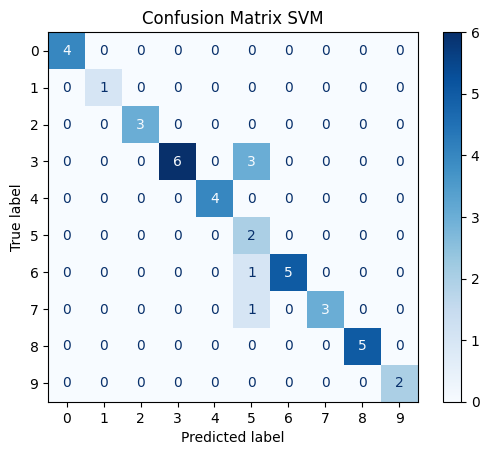

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         9
           4       1.00      1.00      1.00         4
           5       0.29      1.00      0.44         2
           6       1.00      0.83      0.91         6
           7       1.00      0.75      0.86         4
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         2

    accuracy                           0.88        40
   macro avg       0.93      0.93      0.90        40
weighted avg       0.96      0.88      0.90        40



In [71]:
# 5. Prediksi dan evaluasi
y_pred = svm_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix SVM")
plt.show()

print(classification_report(y_test, y_pred))

In [72]:
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']

#### **UJI MODEL**

In [73]:
# Memuat model yang sudah dilatih
svm_model = joblib.load('svm_model.pkl')

In [94]:
# Daftar file audio baru
folder = "../exFitur"  # Ganti dengan folder Anda
data = []

for filename in os.listdir(folder):
    if filename.endswith(".wav"):
        path = os.path.join(folder, filename)
        features = extract_features(path)
        data.append([filename] + features)

# Buat DataFrame dan simpan ke CSV
columns = ['filename', 'zcr', 'rms'] + [f'mfcc_{i+1}' for i in range(13)]
df_new = pd.DataFrame(data, columns=columns)
df_new.to_csv("audio_uji.csv", index=False)

In [95]:
# 2. Muat CSV baru
df_new = pd.read_csv("audio_uji.csv")
X_new = df_new.drop(['filename'], axis=1)

In [96]:
# 3. Normalisasi fitur (scaler)
scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)

In [97]:
# 4. Prediksi kelas
y_pred = svm_model.predict(X_new_scaled)

In [98]:
# 5. Tampilkan hasil prediksi
df_new['predicted_label'] = y_pred
print(df_new[['filename', 'predicted_label']])

       filename  predicted_label
0      lima.wav                3
1  sembilan.wav                9
2     tujuh.wav                7
